# Extraction Method Comparison — Analysis Notebook

One unified column-level dataframe (`df`) for all downstream analysis. Schema:
- **document**, **method**, **column_name**, **group** (label from definitions), **correctness**, **completeness**, **eval_category**
- **ground_truth**, **predicted** (for hallucination detection)
- **hallucination** (True when GT empty and pred has value, numeric_tolerance only)
- **has_recon_attributions**, **has_agent_attributions**, **has_search_attributions** (document-level)

4 methods: Gemini-2.5-flash-native | Reconciliation (max with Gemini) | Gemini with Parsed Document as text | GPT-4.1 with Parsed Document as text


In [171]:
import json
import csv
from pathlib import Path
import pandas as pd

# Resolve paths (run from repo root or experiment-analysis/)
_candidates = [
    Path.cwd() / 'experiment-scripts',
    (Path.cwd() / '..' / 'experiment-scripts').resolve(),
    Path.cwd(),
]
SCRIPT_BASE = next((p for p in _candidates if p.exists()), None)
if SCRIPT_BASE is None:
    raise FileNotFoundError('Could not find experiment-scripts. Run from repo root or experiment-analysis/.')
REPO_ROOT = SCRIPT_BASE.parent

# ─── Unified METHOD_RUNS (used everywhere) ───
METHOD_RUNS = [
    ('gemini_native', 'Gemini-2.5-flash-native', SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash', None),
    ('reconciliation', 'Reconciliation', REPO_ROOT / 'new_pipeline_outputs' / 'results', 'reconciliation_agent'),
    ('gemini_parsed', 'Gemini with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gemini' / 'results' / 'gemini-2.5-flash', None),
    ('gpt4_parsed', 'GPT-4.1 with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gpt4' / 'results' / 'gpt-4.1', None),
]
GEMINI_NATIVE_RUN = SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash'
PIPELINE_RESULTS = REPO_ROOT / 'new_pipeline_outputs' / 'results'
DEFINITIONS_PATH = REPO_ROOT / 'src' / 'table_definitions' / 'Definitions_with_eval_category.csv'


def load_definitions() -> dict:
    """Map column_name -> group (Label)."""
    out = {}
    with open(DEFINITIONS_PATH, 'r', encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            out[row['Column Name'].strip()] = row['Label'].strip()
    return out


def load_eval_columns(trial_dir: Path) -> dict | None:
    """Load per-column eval data from evaluation_results.json."""
    path = trial_dir / 'evaluation' / 'evaluation_results.json'
    if not path.exists():
        return None
    data = json.loads(path.read_text(encoding='utf-8'))
    return data.get('columns')


def compute_recon_columns(recon_dir: Path, gemini_dir: Path) -> dict | None:
    """Per-column max(recon, gemini) for Reconciliation."""
    recon = load_eval_columns(recon_dir)
    gemini = load_eval_columns(gemini_dir)
    if not recon or not gemini:
        return None
    out = {}
    for col in set(recon) | set(gemini):
        rc, gc = recon.get(col, {}), gemini.get(col, {})
        out[col] = {
            'correctness': max(rc.get('correctness', 0), gc.get('correctness', 0)),
            'completeness': max(rc.get('completeness', 0), gc.get('completeness', 0)),
            'category': rc.get('category') or gc.get('category', ''),
            'ground_truth': rc.get('ground_truth'),
            'predicted': rc.get('predicted'),
        }
    return out


def has_attributions(results_path: Path) -> bool:
    if not results_path.exists():
        return False
    try:
        data = json.loads(results_path.read_text(encoding='utf-8'))
        for v in (data.get('columns') or {}).values():
            if (v.get('attribution') or []):
                return True
        return False
    except Exception:
        return False


def is_empty(val) -> bool:
    if val is None:
        return True
    s = str(val).strip().lower().strip(' .,:;')
    return s in {'', 'nan', 'not applicable', 'not reported', 'not present', 'na', 'n/a', 'not found', 'not available', 'unknown'}


def _trial_dir(run_path: Path, pdf: str, subdir: str | None) -> Path:
    return run_path / pdf / subdir if subdir else run_path / pdf


# Load column -> group mapping
col_to_group = load_definitions()

# Common documents
common_pdfs = None
for _, _, run_path, subdir in METHOD_RUNS:
    if not run_path.exists():
        continue
    pdfs = {d.name for d in run_path.iterdir() if d.is_dir() and d.name != 'dataset'}
    common_pdfs = pdfs if common_pdfs is None else common_pdfs & pdfs
common_pdfs = sorted(common_pdfs or [])

# Build column-level dataframe
rows = []
for pdf in common_pdfs:
    doc_root = PIPELINE_RESULTS / pdf
    has_recon = has_attributions(doc_root / 'reconciliation_agent' / 'reconciled_results.json')
    has_agent = has_attributions(doc_root / 'agent_extractor' / 'extraction_results.json')
    has_search = has_attributions(doc_root / 'search_agent' / 'extraction_results.json')

    for key, label, run_path, subdir in METHOD_RUNS:
        if not run_path.exists():
            continue
        trial_dir = _trial_dir(run_path, pdf, subdir)
        if key == 'reconciliation':
            cols_data = compute_recon_columns(trial_dir, GEMINI_NATIVE_RUN / pdf)
        else:
            cols_data = load_eval_columns(trial_dir)
        if not cols_data:
            continue

        for col_name, v in cols_data.items():
            cat = v.get('category', '')
            gt, pred = v.get('ground_truth'), v.get('predicted')
            hall = (cat == 'numeric_tolerance' and is_empty(gt) and not is_empty(pred))
            rows.append({
                'document': pdf,
                'method': label,
                'column_name': col_name,
                'group': col_to_group.get(col_name, ''),
                'correctness': v.get('correctness', 0),
                'completeness': v.get('completeness', 0),
                'eval_category': cat,
                'ground_truth': gt if gt is not None else '',
                'predicted': pred if pred is not None else '',
                'hallucination': hall,
                'has_recon_attributions': has_recon,
                'has_agent_attributions': has_agent,
                'has_search_attributions': has_search,
            })

df = pd.DataFrame(rows)

# Overall summary (doc-level from column df)
doc_overall = df.groupby(['document', 'method']).agg(
    correctness=('correctness', 'mean'),
    completeness=('completeness', 'mean'),
).reset_index()
doc_overall['overall'] = (doc_overall['correctness'] + doc_overall['completeness']) / 2
summary = doc_overall.groupby('method')[['correctness', 'completeness', 'overall']].mean() * 100
summary = summary.round(2)
summary.columns = ['Correctness (%)', 'Completeness (%)', 'Overall (%)']
print("=== OVERALL RESULTS (all columns) ===")
display(summary)

# Numeric tolerance summary
nt = df[df['eval_category'] == 'numeric_tolerance']
if not nt.empty:
    nt_agg = nt.groupby(['document', 'method'])[['correctness', 'completeness']].mean().reset_index()
    nt_agg['overall'] = (nt_agg['correctness'] + nt_agg['completeness']) / 2 * 100
    nt_summary = nt_agg.groupby('method')['overall'].mean().round(2)
    nt_summary.name = 'Overall (%)'
    print("\n=== NUMERIC TOLERANCE (mean Overall % by method) ===")
    display(nt_summary.to_frame())

# Structured text summary
st = df[df['eval_category'] == 'structured_text']
if not st.empty:
    st_agg = st.groupby(['document', 'method'])[['correctness', 'completeness']].mean().reset_index()
    st_agg['overall'] = (st_agg['correctness'] + st_agg['completeness']) / 2 * 100
    st_summary = st_agg.groupby('method')['overall'].mean().round(2)
    st_summary.name = 'Overall (%)'
    print("\n=== STRUCTURED TEXT (mean Overall % by method) ===")
    display(st_summary.to_frame())

# Hallucinations total by method
hall = df[df['hallucination'] == True]
if not hall.empty:
    hall_cnt = hall.groupby('method').size()
    hall_cnt.name = 'Hallucination count'
    print("\n=== HALLUCINATIONS (total count by method) ===")
    display(hall_cnt.to_frame())
else:
    print("\n=== HALLUCINATIONS: 0 for all methods ===")

OUT_JSON = REPO_ROOT / 'experiment-analysis' / 'extraction_method_comparison.json'
df.to_json(str(OUT_JSON), orient='records', indent=2)
print(f"\nSaved: {OUT_JSON}")


=== OVERALL RESULTS (all columns) ===


,Correctness (%),Completeness (%),Overall (%)
method,,,
GPT-4.1 with Parsed Document as text,83.35,84.92,84.14
Gemini with Parsed Document as text,78.35,76.65,77.50
Gemini-2.5-flash-native,82.48,80.86,81.67
Reconciliation,90.88,91.61,91.25



=== NUMERIC TOLERANCE (mean Overall % by method) ===


,Overall (%)
method,
GPT-4.1 with Parsed Document as text,85.61
Gemini with Parsed Document as text,78.41
Gemini-2.5-flash-native,82.62
Reconciliation,91.64



=== STRUCTURED TEXT (mean Overall % by method) ===


,Overall (%)
method,
GPT-4.1 with Parsed Document as text,77.33
Gemini with Parsed Document as text,71.83
Gemini-2.5-flash-native,77.50
Reconciliation,88.67



=== HALLUCINATIONS (total count by method) ===


,Hallucination count
method,
GPT-4.1 with Parsed Document as text,43
Gemini with Parsed Document as text,132
Gemini-2.5-flash-native,49
Reconciliation,70



Saved: /mnt/data1/nahuja11/Mayo/CoRal-Map-Make/experiment-analysis/extraction_method_comparison.json


### Overall results — per-document (from df)

In [172]:
# Per-document Overall (%) — computed from df
if 'df' in dir() and not df.empty:
    doc_overall = df.groupby(['document', 'method'])[['correctness', 'completeness']].mean().reset_index()
    doc_overall['overall'] = (doc_overall['correctness'] + doc_overall['completeness']) / 2 * 100
    doc_overall['correctness'] *= 100
    doc_overall['completeness'] *= 100
    pivot = doc_overall.pivot(index='document', columns='method', values='overall').round(1)
    attr = df.groupby('document').first()[['has_recon_attributions', 'has_agent_attributions', 'has_search_attributions']]
    disp = pivot.join(attr)
    disp.loc['AVG'] = pivot.mean()
    display(disp)
else:
    print('Run the cell above first to build df.')


,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation,has_recon_attributions,has_agent_attributions,has_search_attributions
document,,,,,,,
NCT00104715_Gravis_GETUG_EU'15,88.20,88.7,80.10,92.10,1.0,1.0,1.0
NCT00268476_Attard_STAMPEDE_Lancet'23,75.20,65.2,75.80,89.50,1.0,1.0,1.0
NCT00268476_James_STAMPEDE_IJC'22,93.20,81.0,83.30,88.70,1.0,1.0,1.0
NCT00309985_Kriayako_CHAARTED_JCO'18,90.80,91.0,95.50,97.60,1.0,1.0,1.0
NCT00309985_Sweeney_CHAARTED_NEJM'15,90.20,83.3,86.70,94.00,1.0,1.0,1.0
NCT01809691_Aggarwal_SWOG1216_JCO'22,85.70,79.3,78.20,93.40,1.0,1.0,1.0
NCT01957436_Fizazi_PEACE1_Lancet'22,80.80,69.4,72.40,84.80,1.0,1.0,1.0
NCT02446405_Sweeney_ENZAMET_Lancet Onc'23,81.20,81.0,79.90,85.70,1.0,1.0,1.0
NCT02799602_Hussain_ARASENS_JCO'23,74.80,56.4,75.90,91.60,1.0,1.0,1.0


### Numeric tolerance — per-document (all 4 methods)

Per-document averages over columns in **numeric_tolerance** category.


In [173]:
# Numeric tolerance — per-document Overall (%) from df (all methods)
if 'df' in dir() and not df.empty:
    nt = df[df['eval_category'] == 'numeric_tolerance']
    agg = nt.groupby(['document', 'method'])[['correctness', 'completeness']].mean().reset_index()
    agg['overall'] = (agg['correctness'] + agg['completeness']) / 2 * 100
    tab = agg.pivot(index='document', columns='method', values='overall').round(1)
    tab.loc['AVG'] = tab.mean(numeric_only=True)
    display(tab)
else:
    print('Run the cell above first to build df.')


method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
document,,,,
NCT00104715_Gravis_GETUG_EU'15,89.5,90.70,78.50,91.60
NCT00268476_Attard_STAMPEDE_Lancet'23,76.2,64.70,76.40,89.30
NCT00268476_James_STAMPEDE_IJC'22,96.5,85.30,86.70,89.70
NCT00309985_Kriayako_CHAARTED_JCO'18,93.2,92.50,98.10,98.10
NCT00309985_Sweeney_CHAARTED_NEJM'15,92.5,87.40,90.70,97.30
NCT01809691_Aggarwal_SWOG1216_JCO'22,85.7,80.40,79.00,93.90
NCT01957436_Fizazi_PEACE1_Lancet'22,81.5,70.30,72.70,85.00
NCT02446405_Sweeney_ENZAMET_Lancet Onc'23,81.5,81.80,79.40,85.50
NCT02799602_Hussain_ARASENS_JCO'23,75.5,51.40,75.50,90.10


### Structured text — per-document (all 4 methods)

Per-document averages over columns in **structured_text** category.


In [174]:
# Structured text — per-document Overall (%) from df (all methods)
if 'df' in dir() and not df.empty:
    st = df[df['eval_category'] == 'structured_text']
    agg = st.groupby(['document', 'method'])[['correctness', 'completeness']].mean().reset_index()
    agg['overall'] = (agg['correctness'] + agg['completeness']) / 2 * 100
    tab = agg.pivot(index='document', columns='method', values='overall').round(1)
    tab.loc['AVG'] = tab.mean(numeric_only=True)
    display(tab)
else:
    print('Run the cell above first to build df.')


method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
document,,,,
NCT00104715_Gravis_GETUG_EU'15,76.70,73.30,90.00,90.00
NCT00268476_Attard_STAMPEDE_Lancet'23,83.30,76.70,80.00,90.00
NCT00268476_James_STAMPEDE_IJC'22,78.30,76.70,66.70,86.70
NCT00309985_Kriayako_CHAARTED_JCO'18,80.00,80.00,80.00,91.70
NCT00309985_Sweeney_CHAARTED_NEJM'15,73.30,68.30,75.00,85.00
NCT01809691_Aggarwal_SWOG1216_JCO'22,95.00,83.30,83.30,98.30
NCT01957436_Fizazi_PEACE1_Lancet'22,75.00,53.30,63.30,78.30
NCT02446405_Sweeney_ENZAMET_Lancet Onc'23,71.70,68.30,75.00,76.70
NCT02799602_Hussain_ARASENS_JCO'23,71.70,60.00,68.30,96.70


### Hallucinations — count by document (numeric_tolerance only, all 4 methods)

Absolute count of **numeric_tolerance** columns where GT was empty but model predicted a value.

In [175]:
# Hallucinations — from df (all 4 methods)
if 'df' in dir() and not df.empty:
    hall = df[df['hallucination'] == True]
    cnt = hall.groupby(['document', 'method']).size().reset_index(name='hallucination_count')
    tab = cnt.pivot(index='document', columns='method', values='hallucination_count').fillna(0).astype(int)
    tab.loc['Total'] = tab.sum()
    display(tab)
else:
    print('Run the cell above first to build df.')

method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
document,,,,
NCT00104715_Gravis_GETUG_EU'15,2,4,14,14
NCT00268476_Attard_STAMPEDE_Lancet'23,12,36,10,6
NCT00268476_James_STAMPEDE_IJC'22,0,2,0,10
NCT00309985_Kriayako_CHAARTED_JCO'18,4,2,2,4
NCT00309985_Sweeney_CHAARTED_NEJM'15,3,4,2,2
NCT01809691_Aggarwal_SWOG1216_JCO'22,2,20,2,0
NCT01957436_Fizazi_PEACE1_Lancet'22,9,27,14,14
NCT02446405_Sweeney_ENZAMET_Lancet Onc'23,6,4,4,4
NCT02799602_Hussain_ARASENS_JCO'23,3,33,1,12


In [176]:
# Hallucination details — from df: {doc: {method: [{column, ground_truth, predicted}, ...]}}
import json
if 'df' in dir() and not df.empty:
    hall = df[df['hallucination'] == True][['document', 'method', 'column_name', 'ground_truth', 'predicted']]
    halluc_by_doc = {doc: {m: [] for m in df['method'].unique()} for doc in df['document'].unique()}
    for (doc, method), g in hall.groupby(['document', 'method']):
        halluc_by_doc[doc][method] = [
            {"column": r.column_name, "ground_truth": r.ground_truth or "", "predicted": r.predicted}
            for _, r in g.iterrows()
        ]
    print(json.dumps(halluc_by_doc, indent=2, ensure_ascii=False))
else:
    print('Run the cell above first to build df.')

{
  "NCT00104715_Gravis_GETUG_EU'15": {
    "Gemini-2.5-flash-native": [
      {
        "column": "Metastases - N (%) | Liver | Treatment",
        "ground_truth": "",
        "predicted": "28 (15%)"
      },
      {
        "column": "Metastases - N (%) | Liver | Control",
        "ground_truth": "",
        "predicted": "23 (12%)"
      },
      {
        "column": "OS Rate (%) | Overall | Treatment",
        "ground_truth": "",
        "predicted": "62.1 mo (95% confidence interval [CI], 49.5–73.7)"
      },
      {
        "column": "OS Rate (%) | Synchronous | Treatment",
        "ground_truth": "",
        "predicted": "52.6 mo (95% CI, 43.3-66.8)"
      },
      {
        "column": "OS Rate (%) | High volume | Control",
        "ground_truth": "",
        "predicted": "35.1 mo (95% CI, 29.9–43.6)"
      },
      {
        "column": "OS Rate (%) | Low volume | Control",
        "ground_truth": "",
        "predicted": "83.4 mo (95% CI, 61.8-NR)"
      },
      {
        "column"

### Extraction source modality analysis — all 4 methods

Using `reconciled_results.json` `source.modality` as the gold-standard attribution for where each column's data lives (text / table / figure). Average Overall (%) by modality × method.

In [177]:
# Modality analysis — uses reconciled_results.json source.modality as gold-standard attribution
if 'df' not in dir() or df.empty:
    print('Run the main data cell first to build df.')
else:
    import json
    from pathlib import Path

    _pipeline = PIPELINE_RESULTS  # defined in cell 1

    # Step 1: build {(doc, column_name) -> modality} from reconciled_results.json
    col_modality = {}
    for doc in df['document'].unique():
        p = _pipeline / doc / 'reconciliation_agent' / 'reconciled_results.json'
        if not p.exists():
            continue
        data = json.loads(p.read_text(encoding='utf-8'))
        for col_name, v in data.get('columns', {}).items():
            modality = (v.get('source') or {}).get('modality', '')
            if modality:
                col_modality[(doc, col_name)] = modality

    # Step 2: add modality to df, exclude columns with no attribution
    df_mod = df.copy()
    df_mod['modality'] = df_mod.apply(
        lambda r: col_modality.get((r['document'], r['column_name']), ''), axis=1
    )
    df_mod = df_mod[df_mod['modality'] != '']

    print(f"Columns with modality attribution: {len(df_mod['document'].unique())} docs, "
          f"{df_mod[['document','column_name']].drop_duplicates().shape[0]} unique (doc, col) pairs")
    print(f"Modality distribution (unique doc×col pairs):")
    print(df_mod[['document','column_name','modality']].drop_duplicates()['modality'].value_counts().to_string())

    # Step 3: compute overall per row, group by (modality, method)
    df_mod = df_mod.copy()
    df_mod['overall'] = (df_mod['correctness'] + df_mod['completeness']) / 2 * 100
    df_mod['correctness_pct'] = df_mod['correctness'] * 100
    df_mod['completeness_pct'] = df_mod['completeness'] * 100

    agg = df_mod.groupby(['modality', 'method'])[['correctness_pct', 'completeness_pct', 'overall']].mean().round(1)

    # Step 4: pivot — modality as rows, method as columns (Overall %)
    method_overall = df_mod.groupby('method')['overall'].mean().round(1)

    for metric, title in [('overall', 'Overall (%)'), ('correctness_pct', 'Correctness (%)'), ('completeness_pct', 'Completeness (%)')]:
        pivot = agg[metric].unstack('method').reindex(['text', 'table', 'figure']).round(1)
        pivot.loc['ALL'] = df_mod.groupby('method')[metric].mean().round(1)
        print(f"\n=== {title} by modality × method ===")
        display(pivot)

    # Column counts per modality for reference
    counts = df_mod[['document','column_name','modality']].drop_duplicates()['modality'].value_counts()
    print(f"\nColumn counts used (unique doc×col pairs): {counts.to_dict()}")

Columns with modality attribution: 10 docs, 1330 unique (doc, col) pairs
Modality distribution (unique doc×col pairs):
modality
text      1014
table      284
figure      32

=== Overall (%) by modality × method ===


method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
modality,,,,
text,87.3,78.1,81.6,91.2
table,73.5,78.2,83.6,91.7
figure,76.6,51.6,65.6,86.7
ALL,84.1,77.5,81.7,91.2



=== Correctness (%) by modality × method ===


method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
modality,,,,
text,87.2,78.4,82.1,91.4
table,70.2,80.6,85.0,88.6
figure,76.6,56.2,71.9,92.2
ALL,83.3,78.3,82.5,90.8



=== Completeness (%) by modality × method ===


method,GPT-4.1 with Parsed Document as text,Gemini with Parsed Document as text,Gemini-2.5-flash-native,Reconciliation
modality,,,,
text,87.4,77.9,81.2,91.0
table,76.8,75.7,82.2,94.9
figure,76.6,46.9,59.4,81.2
ALL,84.9,76.7,80.9,91.6



Column counts used (unique doc×col pairs): {'text': 1014, 'table': 284, 'figure': 32}


### Original/Follow Up column — all trials

For each trial and each baseline: ground truth and predicted value for the **Original/Follow Up** column, and whether the model got it right (overall = 1.0) or wrong. Summary counts: how many correct vs incorrect per model.

In [178]:
import json
from pathlib import Path
import pandas as pd

COL = "Original/Follow Up"
_candidates = [
    Path.cwd() / 'experiment-scripts',
    (Path.cwd() / '..' / 'experiment-scripts').resolve(),
    Path.cwd(),
]
SCRIPT_BASE = next((p for p in _candidates if p.exists()), None)
RUNS = [
    ('Gemini-2.5-flash-native', SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash'),
    ('Gemini with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gemini' / 'results' / 'gemini-2.5-flash'),
]

common_pdfs = None
for _, run_path in RUNS:
    if not run_path.exists():
        continue
    pdfs = {d.name for d in run_path.iterdir() if d.is_dir()}
    common_pdfs = pdfs if common_pdfs is None else common_pdfs & pdfs
common_pdfs = sorted(common_pdfs or [])

rows = []
for pdf in common_pdfs:
    for model_label, run_path in RUNS:
        if not run_path.exists():
            continue
        path = run_path / pdf / 'evaluation' / 'evaluation_results.json'
        if not path.exists():
            continue
        data = json.loads(path.read_text(encoding='utf-8'))
        cols = data.get('columns', {})
        if COL not in cols:
            rows.append({'document': pdf, 'model': model_label, 'ground_truth': None, 'predicted': None, 'correct': None})
            continue
        v = cols[COL]
        gt = v.get('ground_truth', '')
        pred = v.get('predicted', '')
        overall = v.get('overall', 0)
        rows.append({
            'document': pdf,
            'model': model_label,
            'ground_truth': gt if gt is not None else '',
            'predicted': pred if pred is not None else '',
            'correct': overall == 1.0,
        })

df = pd.DataFrame(rows)
display(df)

# Summary: how many right vs wrong per model
print("\n--- Summary (Original/Follow Up) ---")
for model in df['model'].unique():
    sub = df[df['model'] == model]
    valid = sub['correct'].notna()
    right = (sub.loc[valid, 'correct'] == True).sum()
    wrong = (sub.loc[valid, 'correct'] == False).sum()
    print(f"{model}: correct = {int(right)}, wrong = {int(wrong)}")

,document,model,ground_truth,predicted,correct
0,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Follow-up / long-term OS analysis (median foll...,Follow up,True
1,NCT00104715_Gravis_GETUG_EU'15,Gemini with Parsed Document as text,Follow-up / long-term OS analysis (median foll...,Follow up,True
2,NCT00268476_Attard_STAMPEDE_Lancet'23,Gemini-2.5-flash-native,Follow Up,Follow Up,True
3,NCT00268476_Attard_STAMPEDE_Lancet'23,Gemini with Parsed Document as text,Follow Up,Follow Up,True
4,NCT00268476_James_STAMPEDE_IJC'22,Gemini-2.5-flash-native,Follow Up,Follow Up,True
5,NCT00268476_James_STAMPEDE_IJC'22,Gemini with Parsed Document as text,Follow Up,Follow up,True
6,NCT00309985_Kriayako_CHAARTED_JCO'18,Gemini-2.5-flash-native,Follow-up / long-term survival analysis,Follow Up,True
7,NCT00309985_Kriayako_CHAARTED_JCO'18,Gemini with Parsed Document as text,Follow-up / long-term survival analysis,Follow up,True
8,NCT00309985_Sweeney_CHAARTED_NEJM'15,Gemini-2.5-flash-native,Original,Original,True
9,NCT00309985_Sweeney_CHAARTED_NEJM'15,Gemini with Parsed Document as text,Original,Original,True



--- Summary (Original/Follow Up) ---
Gemini-2.5-flash-native: correct = 10, wrong = 0
Gemini with Parsed Document as text: correct = 10, wrong = 0


### Region and Race columns — average accuracy by document

For each document and each model: **average overall score** (0–1) over all **Region - N (%)** columns and over all **Race - N (%)** columns. Table shows per-doc per-model averages; then overall mean across documents for each model.

In [179]:
import json
from pathlib import Path
import pandas as pd

_candidates = [
    Path.cwd() / 'experiment-scripts',
    (Path.cwd() / '..' / 'experiment-scripts').resolve(),
    Path.cwd(),
]
SCRIPT_BASE = next((p for p in _candidates if p.exists()), None)
RUNS = [
    ('Gemini-2.5-flash-native', SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash'),
    ('Gemini with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gemini' / 'results' / 'gemini-2.5-flash'),
]

common_pdfs = None
for _, run_path in RUNS:
    if not run_path.exists():
        continue
    pdfs = {d.name for d in run_path.iterdir() if d.is_dir()}
    common_pdfs = pdfs if common_pdfs is None else common_pdfs & pdfs
common_pdfs = sorted(common_pdfs or [])

def avg_overall_for_column_prefix(trial_dir: Path, prefix: str):
    path = trial_dir / 'evaluation' / 'evaluation_results.json'
    if not path.exists():
        return None
    data = json.loads(path.read_text(encoding='utf-8'))
    cols = data.get('columns', {})
    scores = [v.get('overall', 0) for c, v in cols.items() if c.startswith(prefix)]
    if not scores:
        return None
    return sum(scores) / len(scores)

rows = []
for pdf in common_pdfs:
    for model_label, run_path in RUNS:
        if not run_path.exists():
            continue
        trial_dir = run_path / pdf
        avg_region = avg_overall_for_column_prefix(trial_dir, 'Region -')
        avg_race = avg_overall_for_column_prefix(trial_dir, 'Race -')
        rows.append({
            'document': pdf,
            'model': model_label,
            'avg_region': avg_region,
            'avg_race': avg_race,
        })

df = pd.DataFrame(rows)
# Show as percentages
df_display = df.copy()
df_display['avg_region (%)'] = (df_display['avg_region'] * 100).round(2)
df_display['avg_race (%)'] = (df_display['avg_race'] * 100).round(2)
display(df_display[['document', 'model', 'avg_region (%)', 'avg_race (%)']])

# Overall average per model (mean across documents)
print("\n--- Average accuracy (mean across documents) ---")
for model in df['model'].unique():
    sub = df[df['model'] == model]
    r = sub['avg_region'].dropna()
    c = sub['avg_race'].dropna()
    print(f"{model}: Region = {r.mean()*100:.2f}% (n={len(r)}), Race = {c.mean()*100:.2f}% (n={len(c)})")

,document,model,avg_region (%),avg_race (%)
0,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,58.33,100.00
1,NCT00104715_Gravis_GETUG_EU'15,Gemini with Parsed Document as text,100.00,100.00
2,NCT00268476_Attard_STAMPEDE_Lancet'23,Gemini-2.5-flash-native,83.33,100.00
3,NCT00268476_Attard_STAMPEDE_Lancet'23,Gemini with Parsed Document as text,91.67,42.86
4,NCT00268476_James_STAMPEDE_IJC'22,Gemini-2.5-flash-native,0.00,100.00
5,NCT00268476_James_STAMPEDE_IJC'22,Gemini with Parsed Document as text,50.00,100.00
6,NCT00309985_Kriayako_CHAARTED_JCO'18,Gemini-2.5-flash-native,100.00,100.00
7,NCT00309985_Kriayako_CHAARTED_JCO'18,Gemini with Parsed Document as text,100.00,100.00
8,NCT00309985_Sweeney_CHAARTED_NEJM'15,Gemini-2.5-flash-native,100.00,92.86
9,NCT00309985_Sweeney_CHAARTED_NEJM'15,Gemini with Parsed Document as text,100.00,92.86



--- Average accuracy (mean across documents) ---
Gemini-2.5-flash-native: Region = 79.58% (n=10), Race = 90.18% (n=10)
Gemini with Parsed Document as text: Region = 84.79% (n=10), Race = 85.89% (n=10)


In [180]:
# All Region and Race columns where both correctness and completeness are zero (with GT and predicted)
import json
from pathlib import Path
import pandas as pd

_candidates = [
    Path.cwd() / 'experiment-scripts',
    (Path.cwd() / '..' / 'experiment-scripts').resolve(),
    Path.cwd(),
]
SCRIPT_BASE = next((p for p in _candidates if p.exists()), None)
RUNS = [
    ('Gemini-2.5-flash-native', SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash'),
    ('Gemini with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gemini' / 'results' / 'gemini-2.5-flash'),
]

common_pdfs = None
for _, run_path in RUNS:
    if not run_path.exists():
        continue
    pdfs = {d.name for d in run_path.iterdir() if d.is_dir()}
    common_pdfs = pdfs if common_pdfs is None else common_pdfs & pdfs
common_pdfs = sorted(common_pdfs or [])

rows = []
for pdf in common_pdfs:
    for model_label, run_path in RUNS:
        if not run_path.exists():
            continue
        path = run_path / pdf / 'evaluation' / 'evaluation_results.json'
        if not path.exists():
            continue
        data = json.loads(path.read_text(encoding='utf-8'))
        for col, v in data.get('columns', {}).items():
            if not (col.startswith('Region -') or col.startswith('Race -')):
                continue
            c_val = v.get('correctness', 0)
            m_val = v.get('completeness', 0)
            if c_val != 0 or m_val != 0:
                continue
            rows.append({
                'document': pdf,
                'model': model_label,
                'column': col,
                'ground_truth': v.get('ground_truth', ''),
                'predicted': v.get('predicted', ''),
            })

df_zero = pd.DataFrame(rows)
# One row per (document, column) with both model outputs side by side
gt = df_zero.groupby(['document', 'column'])['ground_truth'].first().reset_index()
pred_pivot = df_zero.pivot_table(index=['document', 'column'], columns='model', values='predicted', aggfunc='first').reset_index()
merged = gt.merge(pred_pivot, on=['document', 'column'])
print(f"Total Region/Race columns with both scores zero: {len(df_zero)} (shown as {len(merged)} rows, one per doc+column)")
display(merged)

Total Region/Race columns with both scores zero: 63 (shown as 53 rows, one per doc+column)


,document,column,ground_truth,Gemini with Parsed Document as text,Gemini-2.5-flash-native
0,NCT00104715_Gravis_GETUG_EU'15,Region - N (%) | Africa | Control,,NaN,not found
1,NCT00104715_Gravis_GETUG_EU'15,Region - N (%) | Asia | Control,,NaN,not found
2,NCT00104715_Gravis_GETUG_EU'15,Region - N (%) | Asia | Treatment,,NaN,not found
3,NCT00104715_Gravis_GETUG_EU'15,Region - N (%) | North America | Treatment,,NaN,not found
4,NCT00104715_Gravis_GETUG_EU'15,Region - N (%) | Oceania | Control,,NaN,not found
5,NCT00268476_Attard_STAMPEDE_Lancet'23,Race - N (%) | Amer. Indian or Alaska Nat. | C...,,Extraction error,NaN
6,NCT00268476_Attard_STAMPEDE_Lancet'23,Race - N (%) | Amer. Indian or Alaska Nat. | T...,,Extraction error,NaN
7,NCT00268476_Attard_STAMPEDE_Lancet'23,Race - N (%) | Asian | Treatment,,Extraction error,NaN
8,NCT00268476_Attard_STAMPEDE_Lancet'23,Race - N (%) | Black or African American | Con...,,Extraction error,NaN
9,NCT00268476_Attard_STAMPEDE_Lancet'23,Race - N (%) | Other | Control,,Extraction error,NaN


In [181]:
# Extract all columns from all PDFs for a method where correctness and completeness are not more than 1
# (i.e. filter: correctness <= 1 and completeness <= 1; set imperfect_only=True for at least one score < 1)
import json
from pathlib import Path
import pandas as pd

_candidates = [
    Path.cwd() / 'experiment-scripts',
    (Path.cwd() / '..' / 'experiment-scripts').resolve(),
    Path.cwd(),
]
SCRIPT_BASE = next((p for p in _candidates if p.exists()), None)
RUNS = [
    ('Gemini-2.5-flash-native', SCRIPT_BASE / 'baselines_file_search_results' / 'gemini_native' / 'gemini-2.5-flash'),
    ('Gemini with Parsed Document as text', SCRIPT_BASE / 'baseline_landing_ai_w_gemini' / 'results' / 'gemini-2.5-flash'),
]

# Option: set to a single (label, path) to extract for one method only
METHOD_FILTER = None  # None = all methods; or e.g. RUNS[0] for Gemini only

# Option: only include columns where at least one of correctness/completeness is < 1
imperfect_only = False

common_pdfs = None
for _, run_path in RUNS:
    if not run_path.exists():
        continue
    pdfs = {d.name for d in run_path.iterdir() if d.is_dir()}
    common_pdfs = pdfs if common_pdfs is None else common_pdfs & pdfs
common_pdfs = sorted(common_pdfs or [])

runs_to_use = [METHOD_FILTER] if METHOD_FILTER is not None else RUNS
rows = []
for model_label, run_path in runs_to_use:
    if run_path is None or not run_path.exists():
        continue
    for pdf in common_pdfs:
        path = run_path / pdf / 'evaluation' / 'evaluation_results.json'
        if not path.exists():
            continue
        data = json.loads(path.read_text(encoding='utf-8'))
        for col, v in data.get('columns', {}).items():
            c_val = v.get('correctness', 0)
            m_val = v.get('completeness', 0)
            if c_val > 1 or m_val > 1:
                continue
            if imperfect_only and (c_val >= 1 and m_val >= 1):
                continue
            rows.append({
                'document': pdf,
                'method': model_label,
                'column': col,
                'ground_truth': v.get('ground_truth', ''),
                'predicted': v.get('predicted', ''),
                'correctness': c_val,
                'completeness': m_val,
                'overall': v.get('overall'),
                'category': v.get('category'),
            })

df_all_columns = pd.DataFrame(rows)
print(f"Total rows (doc × method × column with correctness, completeness <= 1): {len(df_all_columns)}")

# Write to JSON (list of records)
out_path = Path.cwd() / 'all_columns_filtered.json'
df_all_columns.to_json(out_path, orient='records', indent=2, date_format='iso')
print(f"Written to {out_path}")

display(df_all_columns)

Total rows (doc × method × column with correctness, completeness <= 1): 2660
Written to /mnt/data1/nahuja11/Mayo/CoRal-Map-Make/experiment-analysis/all_columns_filtered.json


,document,method,column,ground_truth,predicted,correctness,completeness,overall,category
0,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Control Arm - N,193 (ADT alone),193,1.0,0.5,0.75,numeric_tolerance
1,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Docetaxel administration - N (%) | Control,0 (0%),127 (65.8%),0.0,0.0,0.00,numeric_tolerance
2,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Docetaxel administration - N (%) | Treatment,192 (100%),192 (100%),1.0,1.0,1.00,numeric_tolerance
3,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Median Follow-Up Duration (mo),83.9 months,83.9 mo,1.0,1.0,1.00,numeric_tolerance
4,NCT00104715_Gravis_GETUG_EU'15,Gemini-2.5-flash-native,Median Age (years) | Control,64.0,64.0 (58.0-70.0),1.0,1.0,1.00,numeric_tolerance
...,...,...,...,...,...,...,...,...,...
2655,NCT02799602_Smith_ARASENS_NEJM'22,Gemini with Parsed Document as text,Treatment Class,Androgen-receptor pathway inhibitor,Androgen-receptor inhibitor (Darolutamide) in ...,1.0,1.0,1.00,structured_text
2656,NCT02799602_Smith_ARASENS_NEJM'22,Gemini with Parsed Document as text,Type of Therapy,Triplet therapy (ADT + docetaxel + AR inhibitor),"darolutamide, androgen-deprivation therapy, an...",1.0,1.0,1.00,structured_text
2657,NCT02799602_Smith_ARASENS_NEJM'22,Gemini with Parsed Document as text,COE_RCT_IND_OVERALL_RJ,Yes,not found,0.0,0.0,0.00,structured_text
2658,NCT02799602_Smith_ARASENS_NEJM'22,Gemini with Parsed Document as text,Class of Agent in Treatment Arm 1,Androgen-receptor inhibitor (darolutamide),androgen-receptor inhibitor,1.0,1.0,1.00,structured_text


### Modality analysis chart — Overall score by evidence source (Text / Table / Figure)

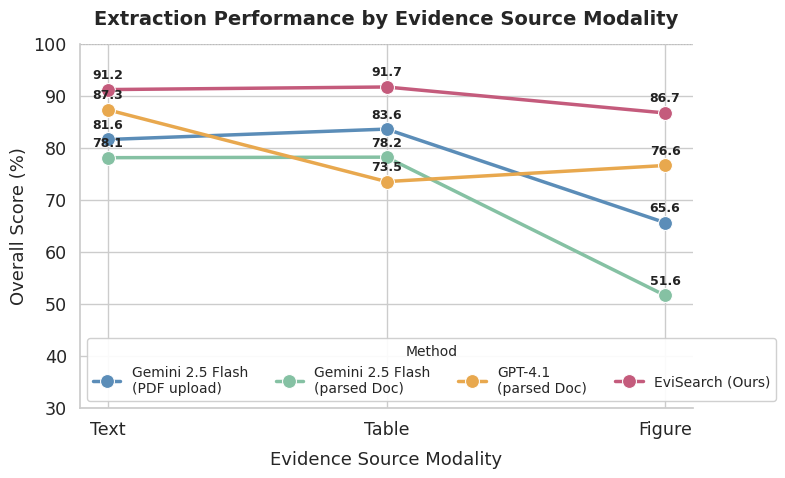

In [182]:
# Modality analysis chart — Overall score by evidence source (Text / Table / Figure) — line plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    'Modality': ['Text', 'Table', 'Figure'],
    'Gemini 2.5 Flash\n(PDF upload)':  [81.6, 83.6, 65.6],
    'Gemini 2.5 Flash\n(parsed Doc)':  [78.1, 78.2, 51.6],
    'GPT-4.1\n(parsed Doc)':           [87.3, 73.5, 76.6],
    'EviSearch (Ours)':                [91.2, 91.7, 86.7],
}

df_mod_chart = pd.DataFrame(data)
long = df_mod_chart.melt(id_vars='Modality', var_name='Method', value_name='Overall (%)')

METHOD_ORDER = [
    'Gemini 2.5 Flash\n(PDF upload)',
    'Gemini 2.5 Flash\n(parsed Doc)',
    'GPT-4.1\n(parsed Doc)',
    'EviSearch (Ours)',
]
PALETTE = {
    'Gemini 2.5 Flash\n(PDF upload)':  '#5B8DB8',
    'Gemini 2.5 Flash\n(parsed Doc)':  '#85C1A3',
    'GPT-4.1\n(parsed Doc)':           '#E8A84E',
    'EviSearch (Ours)':                '#C45B7C',
}
MODALITY_ORDER = ['Text', 'Table', 'Figure']
long['Modality'] = pd.Categorical(long['Modality'], categories=MODALITY_ORDER, ordered=True)

sns.set_theme(style='whitegrid', font_scale=1.15)
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=long, x='Modality', y='Overall (%)', hue='Method',
    palette=PALETTE, hue_order=METHOD_ORDER, sort=False,
    markers=True, marker='o', linewidth=2.5, markersize=10,
    ax=ax,
)

for _, row in long.iterrows():
    xi = MODALITY_ORDER.index(row['Modality'])
    ax.annotate(
        f'{row["Overall (%)"]:.1f}',
        (xi, row['Overall (%)']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, fontweight='bold', color='#222222'
    )

ax.set_ylim(30, 100)
ax.axhline(100, color='#aaaaaa', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Evidence Source Modality', fontsize=13, labelpad=8)
ax.set_ylabel('Overall Score (%)', fontsize=13)
ax.set_title('Extraction Performance by Evidence Source Modality', fontsize=14, fontweight='bold', pad=14)

ax.legend(title='Method', title_fontsize=10, fontsize=10,
          loc='lower left', frameon=True, framealpha=0.92, edgecolor='#cccccc', ncol=4)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


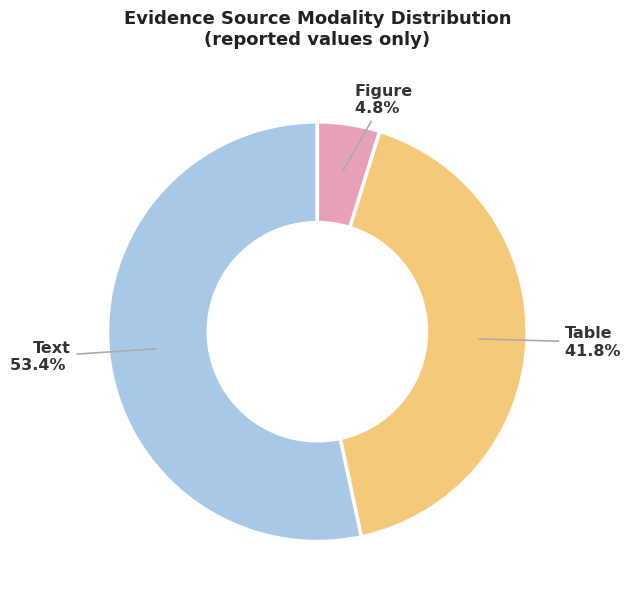

In [183]:
# Modality distribution donut chart — excludes "Not Reported" values (those go to text by default)
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

_pipeline = Path("/mnt/data1/nahuja11/Mayo/CoRal-Map-Make/new_pipeline_outputs/results")
NOT_REPORTED = {'not reported', 'nr', 'n/a', 'na', 'not available', 'not applicable', '', 'none', 'not specified'}

mod_counts = Counter()
for doc_dir in _pipeline.iterdir():
    p = doc_dir / 'reconciliation_agent' / 'reconciled_results.json'
    if not p.exists():
        continue
    data = json.loads(p.read_text(encoding='utf-8'))
    for col_name, v in data.get('columns', {}).items():
        modality = (v.get('source') or {}).get('modality', '')
        if not modality:
            continue
        val = str(v.get('value', '') or '').strip().lower()
        if val in NOT_REPORTED or val.startswith('not report'):
            continue
        mod_counts[modality] += 1

label_map = {'text': 'Text', 'table': 'Table', 'figure': 'Figure'}
counts = {label_map.get(k, k): v for k, v in mod_counts.items()}
labels = ['Text', 'Table', 'Figure']
sizes  = [counts.get(l, 0) for l in labels]
total  = sum(sizes)

COLORS = {'Text': '#A8C8E8', 'Table': '#F5C97A', 'Figure': '#E8A0B8'}
colors = [COLORS[l] for l in labels]

sns.set_theme(style='white', font_scale=1.0)
fig, ax = plt.subplots(figsize=(6.5, 6.5))

wedges, _ = ax.pie(
    sizes, labels=None, colors=colors, startangle=90,
    wedgeprops=dict(width=0.48, edgecolor='white', linewidth=2.5),
)

for wedge, label, size in zip(wedges, labels, sizes):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.radians(angle))
    y = np.sin(np.radians(angle))
    pct = size / total * 100
    ha = 'left' if x > 0 else 'right'
    ax.annotate(
        f'{label}\n{pct:.1f}% ',
        xy=(0.76 * x, 0.76 * y),
        xytext=(1.18 * x, 1.12 * y),
        ha=ha, va='center', fontsize=11.5, fontweight='bold', color='#333333',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=1.2),
    )

ax.set_title('Evidence Source Modality Distribution\n(reported values only)',
             fontsize=13, fontweight='bold', pad=18, color='#222222')

plt.tight_layout()
plt.show()


### Reconciliation yield — A vs B outcomes (human-ready story)

A = agent_extractor, B = search_agent. From reconciled_results.json `verification` field.

In [184]:
# Reconciliation yield — A wins, B wins, both correct, both wrong
import json
from pathlib import Path
from collections import Counter

_pipeline = Path("/mnt/data1/nahuja11/Mayo/CoRal-Map-Make/new_pipeline_outputs/results")

verif_counts = Counter()
for doc_dir in _pipeline.iterdir():
    p = doc_dir / 'reconciliation_agent' / 'reconciled_results.json'
    if not p.exists():
        continue
    data = json.loads(p.read_text(encoding='utf-8'))
    for col_name, v in data.get('columns', {}).items():
        verif = v.get('verification', '')
        if verif:
            verif_counts[verif] += 1

label_map = {
    'both_correct': 'Both correct',
    'A_correct_B_wrong': 'A wins (agent_extractor)',
    'B_correct_A_wrong': 'B wins (search_agent)',
    'both_wrong': 'Both wrong',
}
total = sum(verif_counts.values())

print("=== RECONCILIATION YIELD ===\n")
print(f"{'Outcome':<35} {'Count':>8} {'%':>8}")
print("-" * 52)
for key in ['both_correct', 'A_correct_B_wrong', 'B_correct_A_wrong', 'both_wrong']:
    c = verif_counts.get(key, 0)
    pct = 100 * c / total if total else 0
    print(f"{label_map.get(key, key):<35} {c:>8} {pct:>7.1f}%")
print("-" * 52)
print(f"{'Total':<35} {total:>8} {100.0:>7.1f}%")

# Summary for paper
print("\n--- Key takeaway ---")
both_ok = verif_counts.get('both_correct', 0)
a_wins = verif_counts.get('A_correct_B_wrong', 0)
b_wins = verif_counts.get('B_correct_A_wrong', 0)
both_bad = verif_counts.get('both_wrong', 0)
print(f"  • Both correct: {both_ok:,} ({100*both_ok/total:.1f}%) — dual extraction agrees")
print(f"  • A wins: {a_wins:,} ({100*a_wins/total:.1f}%) — agent_extractor adds value")
print(f"  • B wins: {b_wins:,} ({100*b_wins/total:.1f}%) — search_agent adds value")
print(f"  • Both wrong: {both_bad:,} ({100*both_bad/total:.1f}%) — reconciliation catches & flags")

=== RECONCILIATION YIELD ===

Outcome                                Count        %
----------------------------------------------------
Both correct                            1054    79.2%
A wins (agent_extractor)                 174    13.1%
B wins (search_agent)                     66     5.0%
Both wrong                                36     2.7%
----------------------------------------------------
Total                                   1330   100.0%

--- Key takeaway ---
  • Both correct: 1,054 (79.2%) — dual extraction agrees
  • A wins: 174 (13.1%) — agent_extractor adds value
  • B wins: 66 (5.0%) — search_agent adds value
  • Both wrong: 36 (2.7%) — reconciliation catches & flags


### Evidence availability — % of columns with attribution (page + modality) by method

Demonstrates auditability: how many extractions cite a source (page and modality).

In [185]:
# Evidence availability — % columns with attribution (page + modality)
# Excludes "Not reported" columns (only counts columns with actual extracted values)
import json
from pathlib import Path
import pandas as pd

_pipeline = Path("/mnt/data1/nahuja11/Mayo/CoRal-Map-Make/new_pipeline_outputs/results")
NOT_REPORTED = {'not reported', 'nr', 'n/a', 'na', 'not available', 'not applicable', '', 'none', 'not specified'}

def is_reported(val):
    v = str(val or '').strip().lower()
    return v not in NOT_REPORTED and not v.startswith('not report')

def has_attribution_recon(v):
    """Reconciled: source has page (not null) and modality."""
    src = v.get('source') or {}
    return src.get('page') is not None and bool(src.get('modality'))

def has_attribution_extraction(v):
    """Agent/Search extraction_results: attribution non-empty with page+modality."""
    attrs = v.get('attribution') or []
    return any(a.get('page') is not None and bool(a.get('modality')) for a in attrs)

# Collect per-doc, per-method
rows = []
for doc_dir in _pipeline.iterdir():
    if not doc_dir.is_dir():
        continue
    doc_id = doc_dir.name

    # Reconciliation (final output)
    p_recon = doc_dir / 'reconciliation_agent' / 'reconciled_results.json'
    if p_recon.exists():
        data = json.loads(p_recon.read_text(encoding='utf-8'))
        cols = {k: v for k, v in data.get('columns', {}).items() if is_reported(v.get('value'))}
        total = len(cols)
        with_attr = sum(1 for v in cols.values() if has_attribution_recon(v))
        rows.append({'document': doc_id, 'method': 'EviSearch (reconciled)', 'total': total, 'with_attribution': with_attr})

    # Agent extractor
    p_agent = doc_dir / 'agent_extractor' / 'extraction_results.json'
    if p_agent.exists():
        data = json.loads(p_agent.read_text(encoding='utf-8'))
        cols = {k: v for k, v in data.get('columns', {}).items() if is_reported(v.get('value'))}
        total = len(cols)
        with_attr = sum(1 for v in cols.values() if has_attribution_extraction(v))
        rows.append({'document': doc_id, 'method': 'Agent extractor (A)', 'total': total, 'with_attribution': with_attr})

    # Search agent
    p_search = doc_dir / 'search_agent' / 'extraction_results.json'
    if p_search.exists():
        data = json.loads(p_search.read_text(encoding='utf-8'))
        cols = {k: v for k, v in data.get('columns', {}).items() if is_reported(v.get('value'))}
        total = len(cols)
        with_attr = sum(1 for v in cols.values() if has_attribution_extraction(v))
        rows.append({'document': doc_id, 'method': 'Search agent (B)', 'total': total, 'with_attribution': with_attr})

df_avail = pd.DataFrame(rows)
if df_avail.empty:
    print("No data found.")
else:
    agg = df_avail.groupby('method').agg(total=('total', 'sum'), with_attribution=('with_attribution', 'sum')).reset_index()
    agg['pct'] = (agg['with_attribution'] / agg['total'] * 100).round(1)

    print("=== EVIDENCE AVAILABILITY (auditability) ===\n(reported values only, excludes 'Not reported' columns)\n")
    print(f"{'Method':<30} {'With attribution':>16} {'Total cols':>12} {'%':>8}")
    print("-" * 68)
    for _, r in agg.iterrows():
        print(f"{r['method']:<30} {int(r['with_attribution']):>16} {int(r['total']):>12} {r['pct']:>7.1f}%")

=== EVIDENCE AVAILABILITY (auditability) ===
(reported values only, excludes 'Not reported' columns)

Method                         With attribution   Total cols        %
--------------------------------------------------------------------
Agent extractor (A)                         726          744    97.6%
EviSearch (reconciled)                      663          667    99.4%
Search agent (B)                            562          567    99.1%
